## **Introduzione**

La seguente analisi è stata effettuata utilizzando un dataset che raccoglie i dati sui crimini registrati nella città di **Baltimora (Maryland, USA)** tra gli anni 2010 e 2017.
Il dataset contiene informazioni dettagliate su ogni evento criminale, tra cui **data, ora, tipologia di reato, localizzazione geografica, distretto di polizia e coordinate GPS**, coprendo un ampio periodo temporale.

L'obiettivo dell'analisi è quello di effettuare una classificazione del tipo di arma utilizzata per il crimine, partendo dalle informazioni contenute nel dataset.

Per l'analisi verranno utilizzate librerie Python come **pandas, matplotlib, seaborn, statsmodels, numpy, imbdlearn e sklearn**, che consentiranno di effettuare una **pulizia accurata dei dati, un'analisi esplorativa (EDA) e la modellazione predittiva**.

**N.B.**: Per questioni di compatibilità con le versioni delle librerie, si consiglia di utilizzare la versione **3.12.4** di Python.

In [14]:
# Installazione dei pacchetti necessari
%pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/240.0 kB ? eta -:--:--
   --- ------------------------------------ 20.5/240.0 kB ? eta -:--:--
   ---------------------------------------  235.5/240.0 kB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 240.0/240.0 kB 3.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier 
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

### **Import del dataset**

Si inizia l'analisi importando il dataset in formato `.csv`, disponibile al seguente link ufficiale:
🔗 [City of Baltimore Crime Data](https://data.world/data-society/city-of-baltimore-crime-data)

Per avere una visualizzazione piu' dettagliata del dataset, si consiglia di visionare il file `timeserie.ipynb`, che contiene un'analisi piu' dettagliata delle feature del dataset.

### **Considerazioni preliminari**
Una prima analisi esplorativa (non mostrata qui) ha evidenziato la presenza di valori mancanti, colonne ridondanti e formati non uniformi (in particolare date, orari e coordinate geografiche).

1. **Gestione dei valori mancanti**
   - Le colonne `Location`, `Inside/Outside`, `Weapon`, `District` e    `Neighborhood` presentano una certa quantità di valori nulli.
   - Si sostituiranno i valori con una categoria "Unknown".

2. **Creazione della colonna temporale unificata**
   - Le colonne `CrimeDate` e `CrimeTime` saranno unite in un'unica colonna `Datetime`.

3. **Estrazione di feature temporali**
   - Dalla colonna `DateTime` sono state ricavate variabili derivate:
      - `Year`, `Month`, `Day`, `Hour` e `DayOfWeek`, che consentono analisi più dettagliate sulla distribuzione temporale dei crimini.

4. **Pulizia delle informazioni geografiche**
   - Le colonne `Latitude` e `Longitude` sono state estratte dalla colonna `Location 1`.
   - La colonna `Location 1` ha un formato non uniforme, quindi viene eliminata.

5. **Codifica delle variabili categoriche**
   - Le colonne `CrimeCode`, `Location`, `Description`, `Weapon`, `District`, `Neighborhood` e `DayOfWeek` sono state codificate utilizzando Label Encoding.
   - La variabile `Inside/Outside` è stata mappata manualmente:
      - `I` -> 1 (Interno)
      - `O` -> 0 (Esterno)
      - Valori sconosciuti -> -1

6. **Eliminazione delle colonne originali e salvataggio del dataset**
   - Dopo l'encoding, le colonne categoriche e altre informazioni ridondanti sono state eliminate.
   - Il risultato è un dataset **numerico, privo di valori mancanti** e **codificato**, pronto per essere utilizzato per l'analisi predittiva.

In [36]:
file_path = 'CrimeData.csv'
crime_data = pd.read_csv(file_path)

# ==========================
### Gestione dei valori mancanti
# ==========================
cols_to_fill = ['Location', 'Inside/Outside', 'Weapon', 'District', 'Neighborhood']
for col in cols_to_fill:
    crime_data[col] = crime_data[col].fillna('Unknown')

print("\n--- Valori mancanti dopo il fill ---")
print(crime_data[cols_to_fill].isnull().sum())

# ==========================
### Creazione della colonna DateTime
# ==========================
crime_data['DateTime'] = pd.to_datetime(
    crime_data['CrimeDate'] + ' ' + crime_data['CrimeTime'], 
    errors='coerce'
)
# Rimuovo righe con DateTime non valido
crime_data = crime_data.dropna(subset=['DateTime'])

# Ordino per data e reindicizzo
crime_data = crime_data.sort_values('DateTime').reset_index(drop=True)

# ==========================
### Estrazione di feature temporali
# ==========================
crime_data['Year'] = crime_data['DateTime'].dt.year
crime_data['Month'] = crime_data['DateTime'].dt.month
crime_data['Day'] = crime_data['DateTime'].dt.day
crime_data['Hour'] = crime_data['DateTime'].dt.hour
crime_data['DayOfWeek'] = crime_data['DateTime'].dt.day_name()

# ==========================
### Pulizia della colonna 'Location 1' 
### ed eliminazione 'Total Incidents'
# ==========================

crime_data[['Latitude', 'Longitude']] = crime_data['Location 1'].str.extract(
    r'\((-\d.+),\s+(-\d+)\)'
).astype(float)

crime_data = crime_data.drop(columns=['Location 1'])
crime_data = crime_data.drop(columns=['Post'])

#controllo il range di valori della colonna Total Incidents
print(crime_data['Total Incidents'].unique())

#la colonna Total Incidents ha tutti valori identici pari a 1, quindi rindondante
crime_data = crime_data.drop('Total Incidents', axis=1)


# ==========================
### Label Encoding delle variabili categoriche
# ==========================
categorical_cols = ['CrimeCode', 'Location', 'Description', 
                    'Weapon', 'District', 'Neighborhood', 'DayOfWeek']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    crime_data[f'{col}_encoded'] = le.fit_transform(crime_data[col])
    encoders[col] = le

#label di Inside/Outside
crime_data['Inside/Outside'] = crime_data['Inside/Outside'].map({'I': 1, 'O': 0}).fillna(-1)

# ==========================
### Salvataggio dataset con chiavi di encodings
### e dataset finale
# ==========================


#Creo un dataset degli encoding per fare inverse in futuro
encodings = pd.DataFrame(crime_data[['CrimeCode', 'CrimeCode_encoded', 
                                   'Location', 'Location_encoded', 
                                   'Description', 'Description_encoded',
                                   'Weapon', 'Weapon_encoded', 
                                   'District', 'District_encoded',
                                   'Neighborhood', 'Neighborhood_encoded',
                                   'DayOfWeek', 'DayOfWeek_encoded']])

#salvo tutto il dataset senza colonne categoriche originali (elimino le colonne categoriche)
#elimino anche il date-time, tranne quelli separati

cols_to_drop = ['CrimeCode', 'Location', 'Description', 'Weapon', 
                'District', 'Neighborhood', 'DayOfWeek',
                'CrimeDate', 'CrimeTime', 'DateTime', 'Latitude', 'Longitude']

crime_data = crime_data.drop(columns=[c for c in cols_to_drop if c in crime_data.columns])


--- Valori mancanti dopo il fill ---
Location          0
Inside/Outside    0
Weapon            0
District          0
Neighborhood      0
dtype: int64
[1]


## **Classificazione dell'arma usata**

In questa sezione, si prepara il dataset per un task di classificazione. L'obiettivo è **predire la tipologia di arma utilizzata** in un episodio violento, basandosi su altre caratteristiche dell'evento.

Il modello dovrà classificare ogni episodio in una delle seguenti categorie (la nostra variabile target `weapon`):
* `HANDS`
* `KNIFE`
* `FIREARM`
* `OTHER`

Come input (feature), il classificatore utilizzerà informazioni quali:
* Data dell'episodio
* Luogo
* Descrizione testuale

Come primo passo di preparazione, è necessario pulire la colonna target. Si procede a **filtrare il dataset, eliminando tutte le righe** in cui il valore della colonna `Weapon` è `Unknown`. Questa etichetta non rientra tra le classi di interesse e non è utile per l'addestramento del classificatore.

In [37]:
# Controllo che l'encoding di 'Unknown' sia corretto
weapon_code = encodings.loc[encodings['Weapon'] == 'Unknown', 'Weapon_encoded'].values[0]
print(f'L\' encoding per \'Unknown\' è: ', weapon_code)
print('Numero nuovo di righe del dataset:', crime_data.shape[0])

# Creazione di un nuovo dataset senza 'Unknown'
crime_data_weapon = crime_data[crime_data['Weapon_encoded'] != weapon_code]
print('Numero nuovo di righe del dataset:', crime_data_weapon.shape[0])

L' encoding per 'Unknown' è:  4
Numero nuovo di righe del dataset: 281595
Numero nuovo di righe del dataset: 93184


### **Feature selection**
Si tenta di **filtrare** ulteriormente le feature troppo correlate tra di loro utilizzando una matrice di correlazione per vedere le correlazioni tra coppie di variabili (colonne del dataset) ed eliminando quelle che superano un **threshold** di 0.70.

Questa operazione permette maggiore stabilità della predizione e, possibilmente, interpretabilità del risultato.

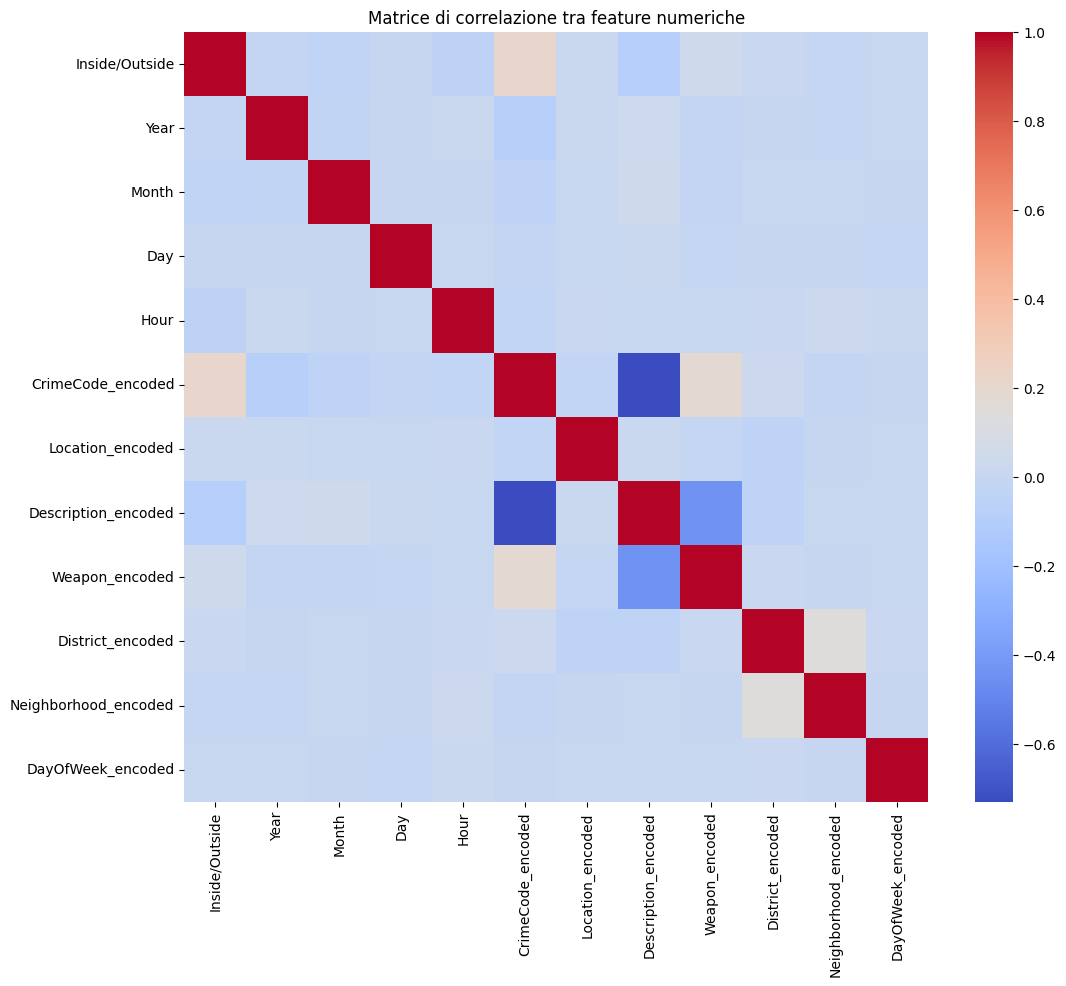

Coppie di feature fortemente correlate:
 CrimeCode_encoded    Description_encoded   -0.729184
Description_encoded  CrimeCode_encoded     -0.729184
dtype: float64


In [38]:
corr_matrix = crime_data_weapon.corr(numeric_only=True)

# Visualizzazione come heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=False)
plt.title("Matrice di correlazione tra feature numeriche")
plt.show()

# Estrai tutte le coppie di correlazioni
corr_pairs = corr_matrix.unstack()

# Filtra le coppie fortemente correlate (escludendo la diagonale 1.0)
high_corr = corr_pairs[(abs(corr_pairs) > 0.7) & (abs(corr_pairs) < 1)]

# Ordina per valore di correlazione
high_corr = high_corr.sort_values(ascending=False)

if high_corr.size == 0:
    print("Non ci sono coppie di feature altamente correlate")
else:
    print("Coppie di feature fortemente correlate:\n", high_corr)

Si decide di **eliminare** la feature `CrimeCode_encoded` in quanto risulta fortemente correlata con la feature `Desription_endoded`.
Inoltre, dal momento che quest'ultima ha una discreta correlazione con la variabile target `Weapon_encoded`, risulta conveniente eliminarne almeno una, al fine di non **influenzare** la classificazione finale.

Si procede con la suddivisione del dataset finale in training (80%) e test (20%).

In [39]:
# Eliminazione delle feature fortemente correlate
crime_data_weapon = crime_data_weapon.drop(columns=['CrimeCode_encoded'])

X = crime_data_weapon.drop('Weapon_encoded', axis=1)
y = crime_data_weapon['Weapon_encoded']

# Split del dataset in train e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Controllo della distribuzione delle classi
print("Distribuzione delle classi nel dataset di training:")
print(y_train.value_counts(normalize=True)*100)
print("Numero di elementi per ogni classe nel dataset di training:")
print(y_train.value_counts())

print("\nDistribuzione delle classi nel dataset di test:")
print(y_test.value_counts(normalize=True)*100)
print("Numero di elementi per ogni classe nel dataset di test:")
print(y_test.value_counts())


Distribuzione delle classi nel dataset di training:
Weapon_encoded
1    55.472387
0    18.494373
3    15.480167
2    10.553074
Name: proportion, dtype: float64
Numero di elementi per ogni classe nel dataset di training:
Weapon_encoded
1    41353
0    13787
3    11540
2     7867
Name: count, dtype: int64

Distribuzione delle classi nel dataset di test:
Weapon_encoded
1    55.470301
0    18.495466
3    15.479959
2    10.554274
Name: proportion, dtype: float64
Numero di elementi per ogni classe nel dataset di test:
Weapon_encoded
1    10338
0     3447
3     2885
2     1967
Name: count, dtype: int64


Seppure le classi risultino **sbilanciate**, proviamo ad effettuare le predizioni mantenendo questa distribuzione di valori, per vedere come i vari modelli si comportano.

Definiamo i classificatori utilizzati per la predizione dell'arma usata. Le tecniche impiegate sono le seguenti:
- **Decision Tree**
- **Random Forest**
- **Ada Boost Classifier**
- **Gradient Boost Classifier**
- **Rete neurale MLP**

In [44]:
# ==============================
# Definizione dei classificatori
# ==============================
classifiers = [
    ("DecisionTreeClassifier", DecisionTreeClassifier(random_state=42), {"max_depth": [10,13,15,18, 20, 23]}),
    ("RandomForestClassifier", RandomForestClassifier(random_state=42), {"n_estimators": [5,10,15, 25, 30], "max_depth": [10,13,15,18, 20, 23]}),
    ("AdaBoostClassifier", AdaBoostClassifier(random_state=42), {"n_estimators": [5,10,15, 25, 30]}),
    ("GradientBoostingClassifier", GradientBoostingClassifier(random_state=42), {"n_estimators": [5,15,25, 25, 30]}),
    ("NeuralNetwork", Pipeline([
        ('scaler', StandardScaler()),
        ('clf', MLPClassifier(
            hidden_layer_sizes=(64, 32, 16), 
            activation='relu',
            solver='adam',
            max_iter=100,
            random_state=42
        ))
    ]), {"clf__hidden_layer_sizes": [(64,32,16),(32,16,8)], "clf__max_iter": [300,400]})
]

def train_and_evaluate_models(classifiers, X_train, y_train, X_test, y_test):
    """
    Esegue addestramento e GridSearch per ogni classificatore,
    salvando modelli, metriche, confusion matrix e probabilità.
    """
    results = {}

    for name, model, param_grid in classifiers:
        print(f"\n🔹 Addestramento e ricerca iperparametri per {name}...")

        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=4,
            scoring='accuracy',
            n_jobs=-1
        )
        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        y_pred = best_model.predict(X_test)
        cm = confusion_matrix(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)

        # Calcolo probabilità se disponibile
        y_proba = best_model.predict_proba(X_test) if hasattr(best_model, "predict_proba") else None

        results[name] = {
            'best_model': best_model,
            'best_params': grid.best_params_,
            'accuracy': best_model.score(X_test, y_test),
            'report': report,
            'confusion_matrix': cm,
            'y_pred': y_pred,
            'y_proba': y_proba
        }

    return results   

def summarize_metrics(results):
    """
    Crea un DataFrame con le principali metriche per ogni modello.
    """
    metrics_summary = pd.DataFrame([
        {
            "Modello": name,
            "Accuracy": res['accuracy'],
            "Precision (macro)": res['report']['macro avg']['precision'],
            "Recall (macro)": res['report']['macro avg']['recall'],
            "F1-score (macro)": res['report']['macro avg']['f1-score']
        }
        for name, res in results.items()
    ])

    print("\n📊 CONFRONTO FINALE DELLE METRICHE:\n")
    print(metrics_summary.to_string(index=False))
    return metrics_summary

def plot_accuracy_bar(metrics_summary):
    """
    Crea un grafico a barre per l'Accuracy
    """
    plt.figure(figsize=(8, 5))
    plt.bar(metrics_summary["Modello"], metrics_summary["Accuracy"], color='skyblue')
    plt.title("Confronto Accuracy tra Classificatori")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=30, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(results, cols=3):
    """
    Crea un grafico con le matrici di confusione in un unico grafico
    """
    num_models = len(results)
    rows = int(np.ceil(num_models / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 5 * rows))
    axes = axes.flatten()

    for ax, (name, res) in zip(axes, results.items()):
        disp = ConfusionMatrixDisplay(res['confusion_matrix'])
        disp.plot(cmap='Blues', ax=ax, colorbar=False)
        ax.set_title(name, fontsize=12)
        ax.grid(False)

    # Rimuove assi vuoti
    for j in range(len(results), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("Confronto Matrici di Confusione", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

def plot_roc_curves(results, y_test, cols=3):
    """
    Crea un grafico con le curve ROC per ogni classe
    """
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)

    num_models = len(results)
    rows = int(np.ceil(num_models / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(7 * cols, 5 * rows))
    axes = axes.flatten()

    for ax, (name, res) in zip(axes, results.items()):
        if res['y_proba'] is not None:
            y_proba = res['y_proba']
            for i, c in enumerate(classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, label=f"Classe {c} (AUC={roc_auc:.2f})")

            ax.plot([0, 1], [0, 1], 'k--', alpha=0.6)
            ax.set_title(name, fontsize=12)
            ax.set_xlabel("False Positive Rate")
            ax.set_ylabel("True Positive Rate")
            ax.legend(loc="lower right", fontsize=8)
            ax.grid(True, linestyle='--', alpha=0.4)
        else:
            ax.set_visible(False)

    # Rimuove assi vuoti
    for j in range(len(results), len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle("ROC Multiclasse – Confronto tra Modelli", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()
    
def plot_neural_network_loss(results):
    """
    Crea un grafico per la Loss della rete neurale
    """
    if "NeuralNetwork" in results:
        clf = results["NeuralNetwork"]["best_model"].named_steps['clf']
        if hasattr(clf, "loss_curve_"):
            plt.figure(figsize=(6, 4))
            plt.plot(clf.loss_curve_)
            plt.title("Rete neurale - Andamento del Loss")
            plt.xlabel("Epoca")
            plt.ylabel("Loss")
            plt.grid(True)
            plt.tight_layout()
            plt.show()


🔹 Addestramento e ricerca iperparametri per DecisionTreeClassifier...

🔹 Addestramento e ricerca iperparametri per RandomForestClassifier...

🔹 Addestramento e ricerca iperparametri per AdaBoostClassifier...


C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



🔹 Addestramento e ricerca iperparametri per GradientBoostingClassifier...

🔹 Addestramento e ricerca iperparametri per NeuralNetwork...

📊 CONFRONTO FINALE DELLE METRICHE:

                   Modello  Accuracy  Precision (macro)  Recall (macro)  F1-score (macro)
    DecisionTreeClassifier  0.773139           0.613429        0.622861          0.602140
    RandomForestClassifier  0.796480           0.656604        0.662999          0.651591
        AdaBoostClassifier  0.673553           0.539795        0.488317          0.394590
GradientBoostingClassifier  0.776573           0.606109        0.621335          0.565039
             NeuralNetwork  0.775500           0.614702        0.625977          0.601244


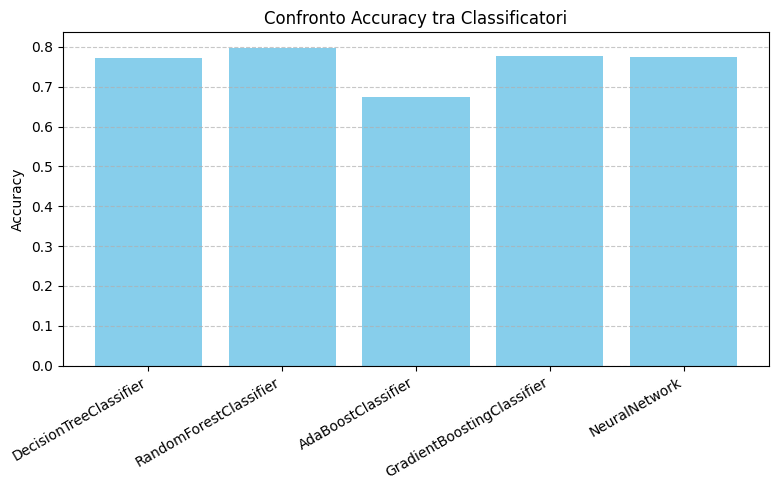

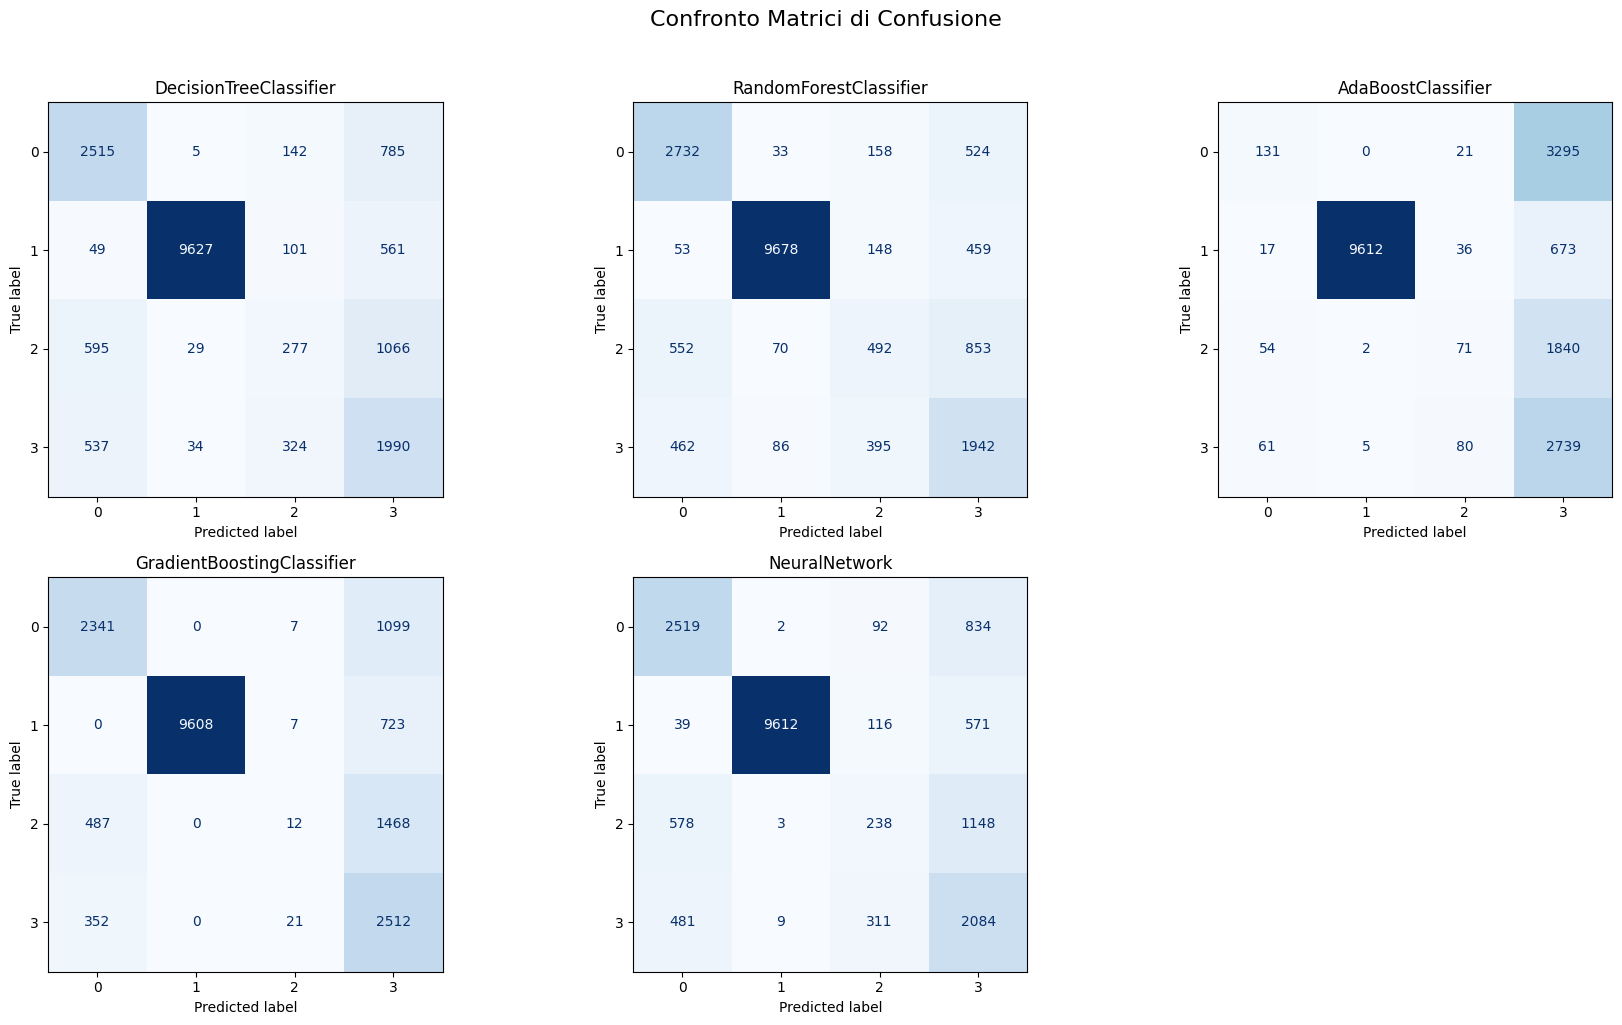

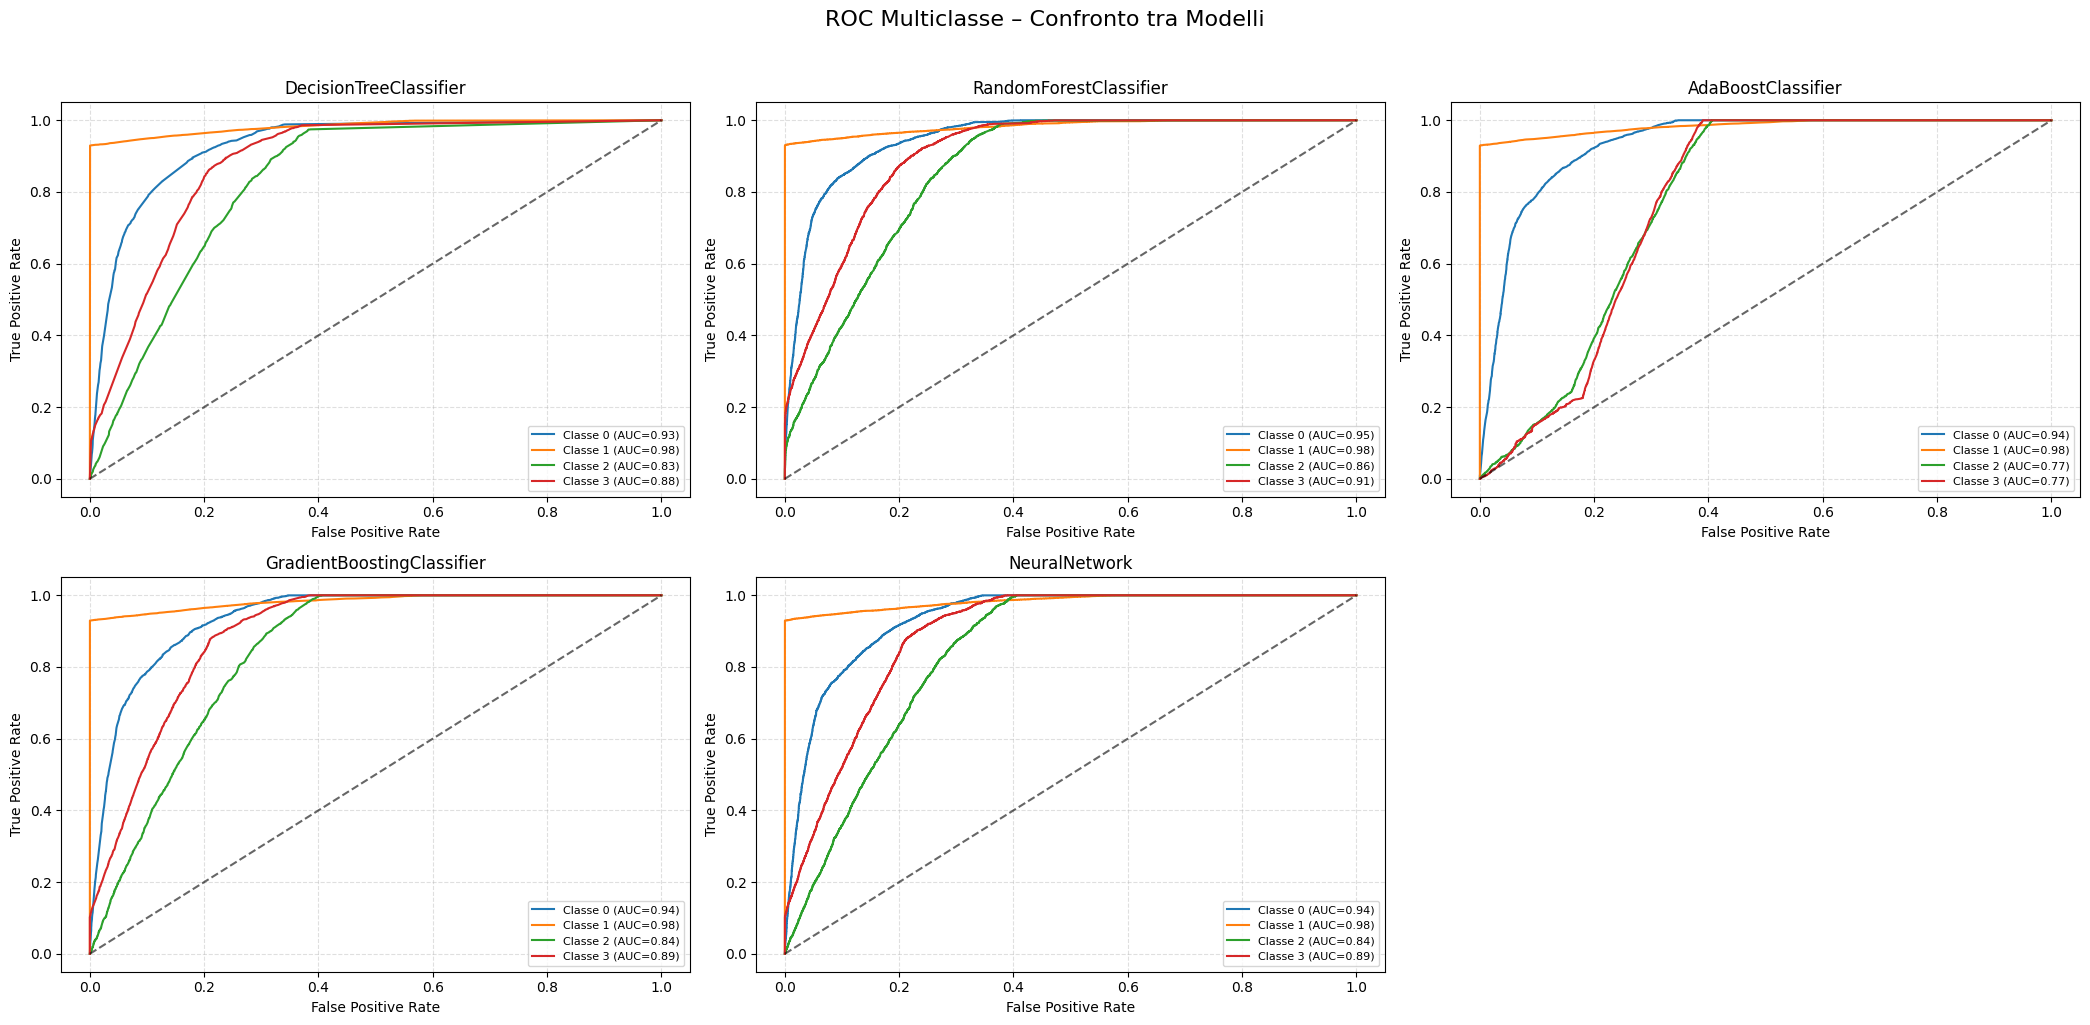

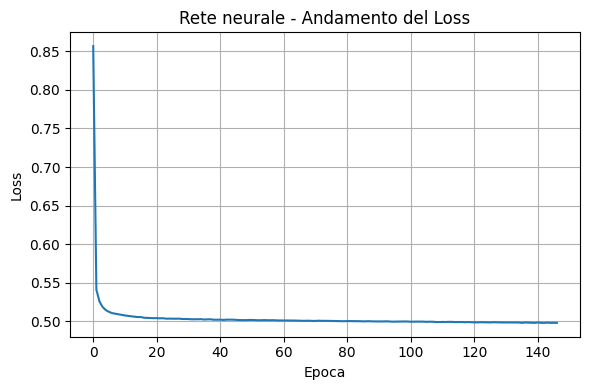

In [45]:
# Addestramento e ricerca iperparametri per ogni classificatore
results = train_and_evaluate_models(classifiers, X_train, y_train, X_test, y_test)

# Visualizzazione dei risultati
metrics_summary = summarize_metrics(results)
plot_accuracy_bar(metrics_summary)
plot_confusion_matrices(results)
plot_roc_curves(results, y_test)
plot_neural_network_loss(results)

Dal momento che le predizioni risultano discrete per la classe maggioritaria 1 ('HANDS'), ma piuttosto povere per le restanti classi, tentiamo un upsampling.

Si intende aumentare artificialmente il numero di campioni presenti nel dataset di training, inerenti alle classi 0 ('FIREARM'), 2 ('KNIFE') e 3 ('OTHER).

Si utilizzerà la funzione

In [ ]:
# Uitlizzo di SMOTE per aumentare il numero di esempi minoritari
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Visualizzazione dei dati aumentati
print("Distribuzione delle classi nel dataset di training aumentato:")
print(y_train_res.value_counts(normalize=True)*100)
print(y_train_res.value_counts())

Notiamo che le classi minoritarie (0, 2 e 3) sono state **incrementate** fino a raggiungere il numero di campioni della classse maggioritaria 1, con 41353 records.

Effettuiamo nuovamente le predizioni.


🔹 Addestramento e ricerca iperparametri per DecisionTreeClassifier...
Migliori parametri trovati: {'max_depth': 23}


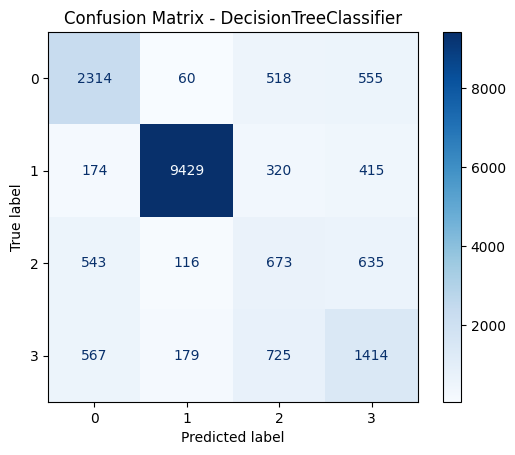

              precision    recall  f1-score   support

           0       0.64      0.67      0.66      3447
           1       0.96      0.91      0.94     10338
           2       0.30      0.34      0.32      1967
           3       0.47      0.49      0.48      2885

    accuracy                           0.74     18637
   macro avg       0.59      0.60      0.60     18637
weighted avg       0.76      0.74      0.75     18637



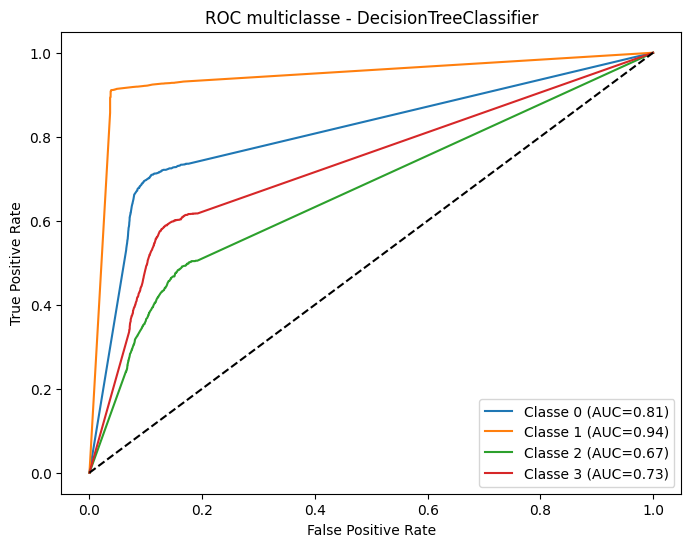


🔹 Addestramento e ricerca iperparametri per RandomForestClassifier...
Migliori parametri trovati: {'max_depth': 23, 'n_estimators': 30}


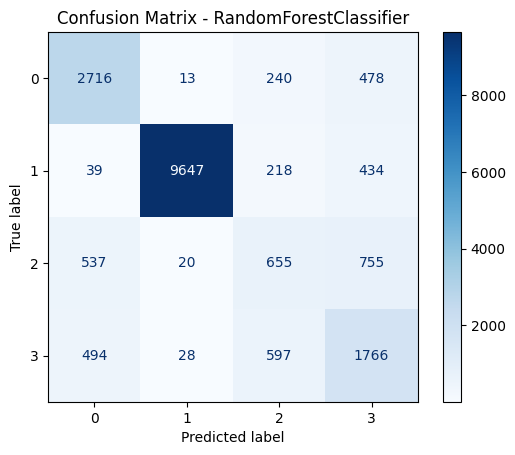

              precision    recall  f1-score   support

           0       0.72      0.79      0.75      3447
           1       0.99      0.93      0.96     10338
           2       0.38      0.33      0.36      1967
           3       0.51      0.61      0.56      2885

    accuracy                           0.79     18637
   macro avg       0.65      0.67      0.66     18637
weighted avg       0.80      0.79      0.80     18637



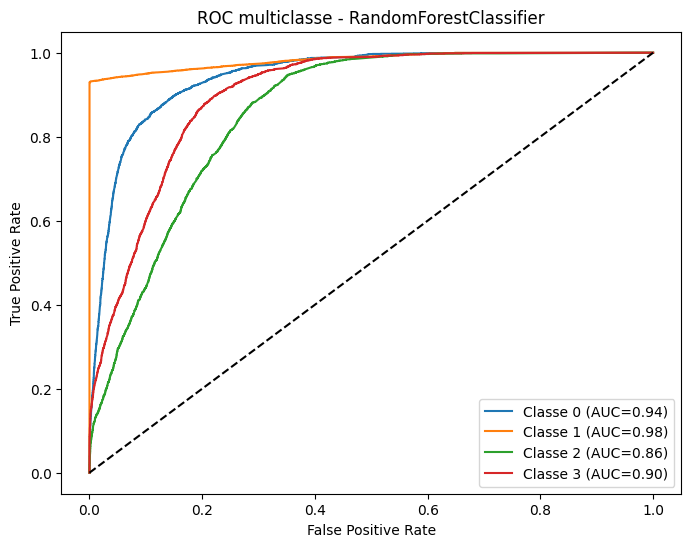


🔹 Addestramento e ricerca iperparametri per AdaBoostClassifier...


C:\Users\matte\AppData\Roaming\Python\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Migliori parametri trovati: {'n_estimators': 30}


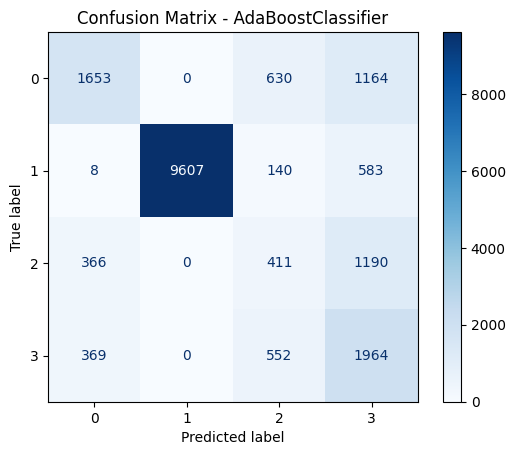

              precision    recall  f1-score   support

           0       0.69      0.48      0.57      3447
           1       1.00      0.93      0.96     10338
           2       0.24      0.21      0.22      1967
           3       0.40      0.68      0.50      2885

    accuracy                           0.73     18637
   macro avg       0.58      0.57      0.56     18637
weighted avg       0.77      0.73      0.74     18637



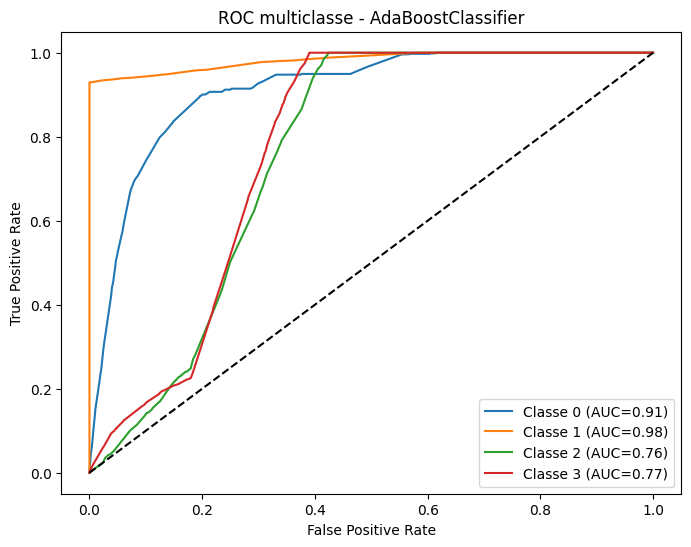


🔹 Addestramento e ricerca iperparametri per GradientBoostingClassifier...
Migliori parametri trovati: {'n_estimators': 30}


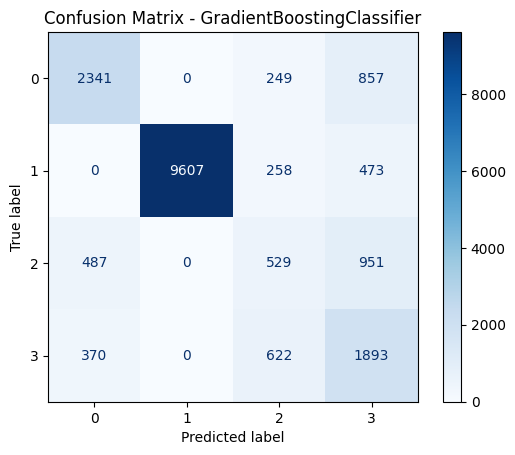

              precision    recall  f1-score   support

           0       0.73      0.68      0.70      3447
           1       1.00      0.93      0.96     10338
           2       0.32      0.27      0.29      1967
           3       0.45      0.66      0.54      2885

    accuracy                           0.77     18637
   macro avg       0.63      0.63      0.62     18637
weighted avg       0.79      0.77      0.78     18637



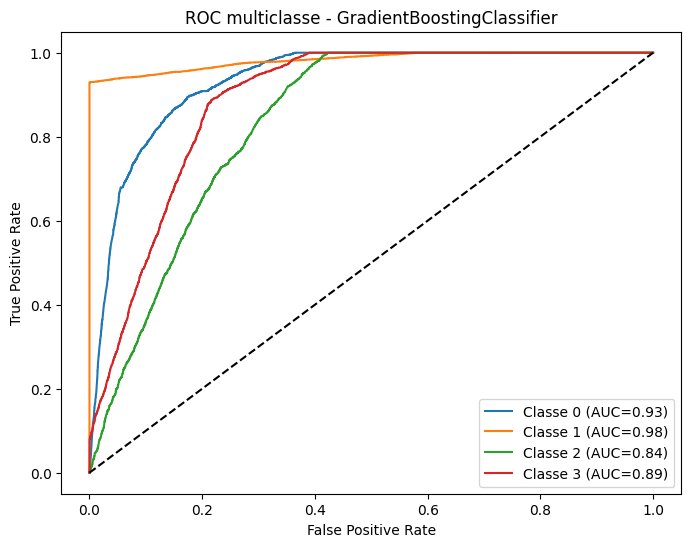


🔹 Addestramento e ricerca iperparametri per NeuralNetwork...
Migliori parametri trovati: {'clf__hidden_layer_sizes': (64, 32, 16), 'clf__max_iter': 400}


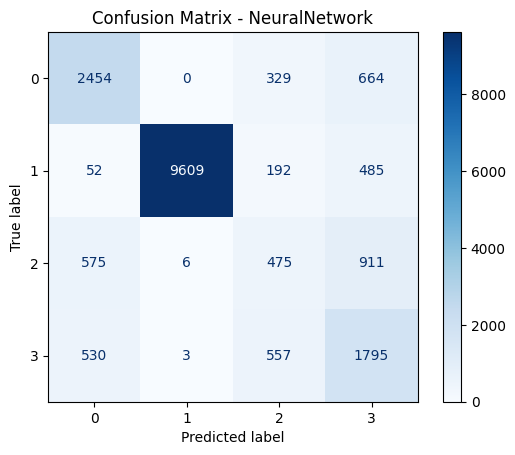

              precision    recall  f1-score   support

           0       0.68      0.71      0.70      3447
           1       1.00      0.93      0.96     10338
           2       0.31      0.24      0.27      1967
           3       0.47      0.62      0.53      2885

    accuracy                           0.77     18637
   macro avg       0.61      0.63      0.62     18637
weighted avg       0.78      0.77      0.77     18637



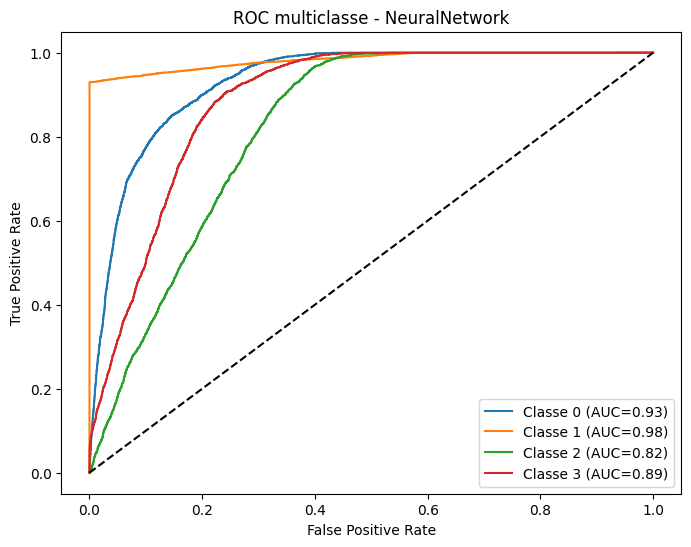

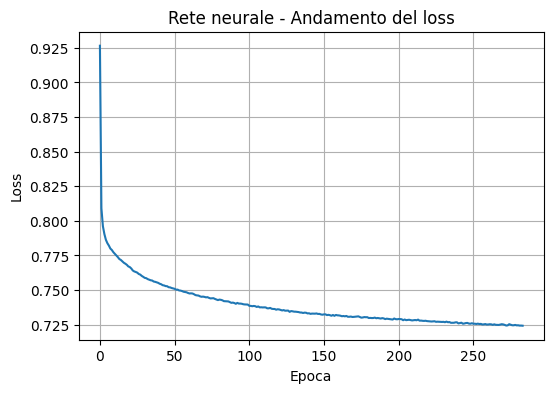

In [ ]:
# Addestramento e ricerca iperparametri per ogni classificatore (con SMOTE)
results = train_and_evaluate_models(classifiers, X_train, y_train, X_test, y_test)

# Visualizzazione dei risultati con SMOTE
metrics_summary = summarize_metrics(results)
plot_accuracy_bar(metrics_summary)
plot_confusion_matrices(results)
plot_roc_curves(results, y_test)
plot_neural_network_loss(results)